# Multi-Class Resume Classification Model — v2 (Combined Dataset)

New in v2:

Combined 3 datasets → ~2835 resumes
Added 8 new tech categories (Frontend Dev, Backend Dev, ML Engineer, etc.)
Added 24 general categories (Accountant, Advocate, Agriculture, etc.)
Total: 51 categories (categories with < 5 samples filtered out for reliable training)

Pipeline Overview:
1. **Data Loading & Combining** — Load all 3 CSVs, normalize & merge
2. **Text Cleaning** — Remove noise using Regular Expressions
3. **NLP Preprocessing** — Lemmatization & Stopword Removal using spaCy
4. **Feature Extraction** — TF-IDF Vectorization
5. **Model Building** — OneVsRestClassifier + KNeighborsClassifier
6. **Evaluation** — Classification Report, Accuracy Score & Confusion Matrix
7. **Save Models** — For FastAPI deployment

---
## Step 1 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import re
import warnings
import spacy
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# Load spaCy English model
nlp = spacy.load('en_core_web_sm')

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## Step 2 - Data Loading & Combining

We combine **3 datasets**:
| Dataset | Rows | Categories | Notes |
|---------|------|------------|-------|
| `UpdatedResumeDataSet.csv` | 962 | 25 | Original tech-focused |
| `resume_dataset.csv` | 400 | 8 | New modern tech roles |
| `Resume.csv` | 2484 | 24 | General domains (UPPERCASE) |

**Strategy:** Normalize category names → combine → remove duplicates → filter categories with < 5 samples

In [2]:
#  Dataset 1: UpdatedResumeDataSet.csv (Original)
df1 = pd.read_csv('Dataset/UpdatedResumeDataSet.csv')
print(f'Dataset 1 — UpdatedResumeDataSet.csv')
print(f'  Shape     : {df1.shape}')
print(f'  Categories: {df1["Category"].nunique()}')
print(f'  Cats      : {sorted(df1["Category"].unique().tolist())}')
df1.head(2)

Dataset 1 — UpdatedResumeDataSet.csv
  Shape     : (962, 2)
  Categories: 25
  Cats      : ['Advocate', 'Arts', 'Automation Testing', 'Blockchain', 'Business Analyst', 'Civil Engineer', 'Data Science', 'Database', 'DevOps Engineer', 'DotNet Developer', 'ETL Developer', 'Electrical Engineering', 'HR', 'Hadoop', 'Health and fitness', 'Java Developer', 'Mechanical Engineer', 'Network Security Engineer', 'Operations Manager', 'PMO', 'Python Developer', 'SAP Developer', 'Sales', 'Testing', 'Web Designing']


,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...


In [3]:
#  Dataset 2: resume_dataset.csv (New Tech Categories)
df2 = pd.read_csv('Dataset/resume_dataset.csv')
print(f'Dataset 2 - resume_dataset.csv')
print(f'  Shape     : {df2.shape}')
print(f'  Categories: {df2["Category"].nunique()}')
print(f'  Cats      : {sorted(df2["Category"].unique().tolist())}')
df2.head(2)

Dataset 2 - resume_dataset.csv
  Shape     : (400, 2)
  Categories: 8
  Cats      : ['Backend Developer', 'Cloud Engineer', 'Data Scientist', 'Frontend Developer', 'Full Stack Developer', 'Machine Learning Engineer', 'Mobile App Developer (iOS/Android)', 'Python Developer']


,Category,Resume
0,Frontend Developer,"As a seasoned Frontend Developer, I have a pro..."
1,Backend Developer,With a solid background in Backend Development...


In [4]:
#  Dataset 3: Resume.csv (General Categories, UPPERCASE)
df3_raw = pd.read_csv('Dataset/Resume.csv')
print(f'Dataset 3 — Resume.csv (RAW)')
print(f'  Shape   : {df3_raw.shape}')
print(f'  Columns : {df3_raw.columns.tolist()}')
print(f'  Cats    : {sorted(df3_raw["Category"].unique().tolist())}')

# Map UPPERCASE category names → proper Title Case
category_map = {
    'ACCOUNTANT': 'Accountant',
    'ADVOCATE': 'Advocate',
    'AGRICULTURE': 'Agriculture',
    'APPAREL': 'Apparel',
    'ARTS': 'Arts',
    'AUTOMOBILE': 'Automobile',
    'AVIATION': 'Aviation',
    'BANKING': 'Banking',
    'BPO': 'BPO',
    'BUSINESS-DEVELOPMENT': 'Business Development',
    'CHEF': 'Chef',
    'CONSTRUCTION': 'Construction',
    'CONSULTANT': 'Consultant',
    'DESIGNER': 'Designer',
    'DIGITAL-MEDIA': 'Digital Media',
    'ENGINEERING': 'Engineering',
    'FINANCE': 'Finance',
    'FITNESS': 'Health and fitness',  # matches DS1 category name
    'HEALTHCARE': 'Healthcare',
    'HR': 'HR',
    'INFORMATION-TECHNOLOGY': 'Information Technology',
    'PUBLIC-RELATIONS': 'Public Relations',
    'SALES': 'Sales',               # merges with DS1 Sales
    'TEACHER': 'Teacher',
}

df3 = pd.DataFrame({
    'Category': df3_raw['Category'].map(category_map),
    'Resume': df3_raw['Resume_str']
})
df3 = df3.dropna(subset=['Category', 'Resume'])
df3 = df3[df3['Resume'].str.strip() != '']

print(f'\nDataset 3 - Resume.csv (CLEANED)')
print(f'  Shape     : {df3.shape}')
print(f'  Categories: {df3["Category"].nunique()}')
df3.head(2)

Dataset 3 — Resume.csv (RAW)
  Shape   : (2484, 4)
  Columns : ['ID', 'Resume_str', 'Resume_html', 'Category']
  Cats    : ['ACCOUNTANT', 'ADVOCATE', 'AGRICULTURE', 'APPAREL', 'ARTS', 'AUTOMOBILE', 'AVIATION', 'BANKING', 'BPO', 'BUSINESS-DEVELOPMENT', 'CHEF', 'CONSTRUCTION', 'CONSULTANT', 'DESIGNER', 'DIGITAL-MEDIA', 'ENGINEERING', 'FINANCE', 'FITNESS', 'HEALTHCARE', 'HR', 'INFORMATION-TECHNOLOGY', 'PUBLIC-RELATIONS', 'SALES', 'TEACHER']

Dataset 3 - Resume.csv (CLEANED)
  Shape     : (2483, 2)
  Categories: 24


,Category,Resume
0,HR,HR ADMINISTRATOR/MARKETING ASSOCIATE\...
1,HR,"HR SPECIALIST, US HR OPERATIONS ..."


In [5]:
#  Combine All 3 Datasets
df = pd.concat([df1, df2, df3], ignore_index=True)

# Remove nulls and exact duplicate resumes
df = df.dropna(subset=['Category', 'Resume'])
df = df.drop_duplicates(subset=['Resume'])
df = df.reset_index(drop=True)

print(f'After combining & deduplication: {df.shape}')

#  Filter: Remove categories with fewer than 5 samples
MIN_SAMPLES = 5
cat_counts = df['Category'].value_counts()
valid_cats = cat_counts[cat_counts >= MIN_SAMPLES].index
df = df[df['Category'].isin(valid_cats)].reset_index(drop=True)

print(f'After filtering (min {MIN_SAMPLES} samples): {df.shape}')
print(f'Null values: {df.isnull().sum().to_dict()}')
print()

# Final summary
print(f' FINAL COMBINED DATASET ')
print(f'Total Rows       : {len(df)}')
print(f'Total Categories : {df["Category"].nunique()}')
print()
print('Category breakdown (sorted by count):')
for cat, count in df['Category'].value_counts().items():
    bar = '█' * (count // 10)
    print(f'  {cat:<35} : {count:4d}  {bar}')

After combining & deduplication: (2835, 2)
After filtering (min 5 samples): (2824, 2)
Null values: {'Category': 0, 'Resume': 0}

 FINAL COMBINED DATASET 
Total Rows       : 2824
Total Categories : 48

Category breakdown (sorted by count):
  Advocate                            :  128  ████████████
  Health and fitness                  :  123  ████████████
  Sales                               :  121  ████████████
  HR                                  :  120  ████████████
  Information Technology              :  120  ████████████
  Business Development                :  119  ███████████
  Engineering                         :  118  ███████████
  Chef                                :  118  ███████████
  Accountant                          :  118  ███████████
  Finance                             :  117  ███████████
  Aviation                            :  116  ███████████
  Consultant                          :  115  ███████████
  Banking                             :  115  ███████████
  

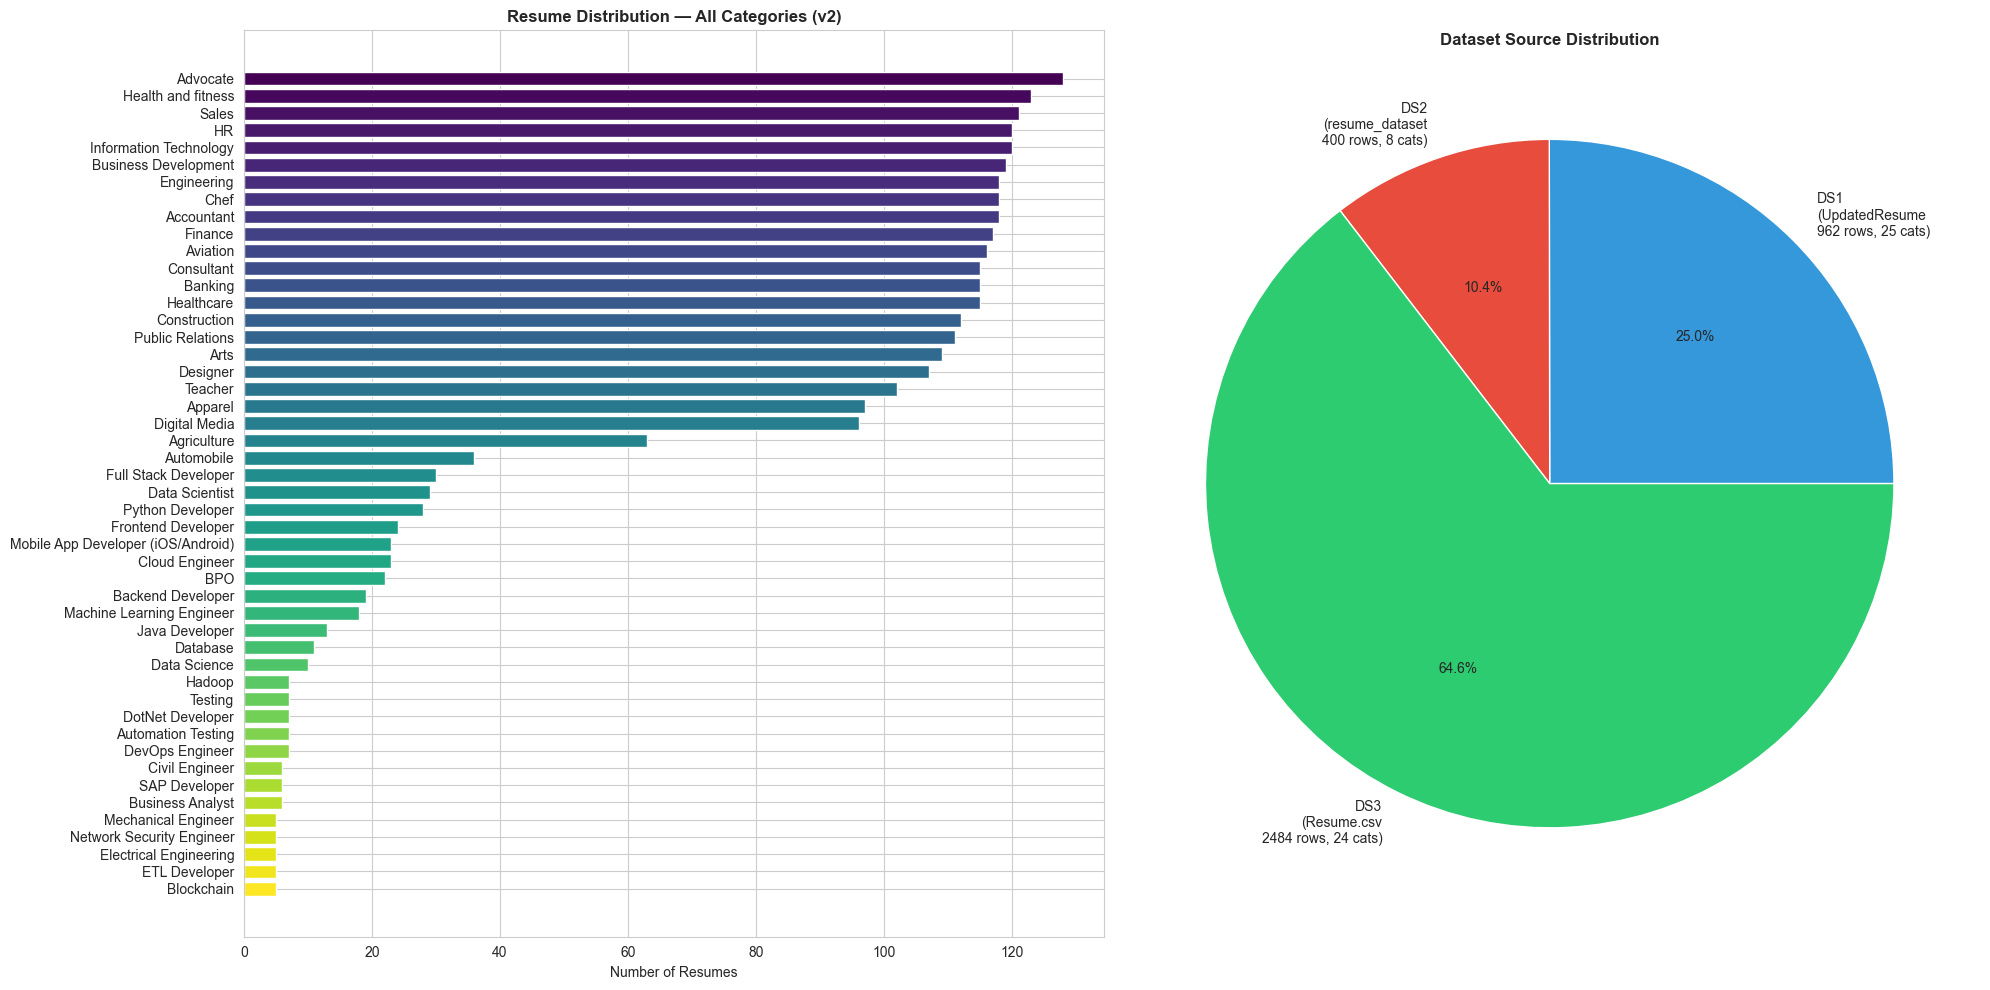

v1: 962 resumes, 25 categories
v2: 2824 resumes, 48 categories (+1862 more resumes!)


In [6]:
#  Category Distribution Plot
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Full distribution (all categories)
counts = df['Category'].value_counts()
colors = plt.cm.viridis(np.linspace(0, 1, len(counts)))
axes[0].barh(counts.index, counts.values, color=colors)
axes[0].set_xlabel('Number of Resumes')
axes[0].set_title(
    'Resume Distribution — All Categories (v2)', fontweight='bold')
axes[0].invert_yaxis()

# Dataset source breakdown
ds_labels = (['DS1 (UpdatedResume)'] * len(df1) +
             ['DS2 (resume_dataset)'] * len(df2) +
             ['DS3 (Resume.csv)'] * len(df3))
# Only for rows still in df
source_counts = pd.Series({
    'DS1\n(UpdatedResume\n962 rows, 25 cats)': len(df1),
    'DS2\n(resume_dataset\n400 rows, 8 cats)': len(df2),
    'DS3\n(Resume.csv\n2484 rows, 24 cats)': len(df3)
})
axes[1].pie(source_counts.values, labels=source_counts.index,
            autopct='%1.1f%%', colors=['#3498db', '#e74c3c', '#2ecc71'])
axes[1].set_title('Dataset Source Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'v1: 962 resumes, 25 categories')
print(
    f'v2: {len(df)} resumes, {df["Category"].nunique()} categories (+{len(df)-962} more resumes!)')

---
## Step 3 - Text Cleaning (Regular Expressions)

In [7]:
def clean_text(text: str) -> str:
    """
    Clean raw resume text using Regular Expressions.
    Removes: URLs, RT/cc tags, Hashtags, Mentions, HTML tags,
             special characters, extra whitespace.
    """
    text = str(text)  # ensure string type
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text, flags=re.MULTILINE)
    text = re.sub(r'\bRT\b|\bcc\b', ' ', text)
    text = re.sub(r'#\S+', ' ', text)
    text = re.sub(r'@\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)          # HTML tags
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)   # non-alphabetic chars
    text = re.sub(r'\s+', ' ', text).strip()    # extra whitespace
    return text


# Preview on sample from each dataset
sample_raw = df['Resume'].iloc[0][:300]
sample_clean = clean_text(df['Resume'].iloc[0])[:300]

print(' RAW ')
print(sample_raw)
print('\n CLEANED ')
print(sample_clean)

 RAW 
Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language pr

 CLEANED 
Skills Programming Languages Python pandas numpy scipy scikit learn matplotlib Sql Java JavaScript JQuery Machine learning Regression SVM Na ve Bayes KNN Random Forest Decision Trees Boosting techniques Cluster Analysis Word Embedding Sentiment Analysis Natural Language processing Dimensionality red


In [8]:
df['Cleaned_Resume'] = df['Resume'].apply(clean_text)
print(f'Text cleaning complete. {len(df)} resumes processed.')

Text cleaning complete. 2824 resumes processed.


---
## Step 4  NLP Preprocessing (spaCy: Lemmatization + Stopword Removal)

> 5–15 minutes due to larger dataset (~2835 resumes).

In [9]:
def spacy_preprocess(text: str) -> str:
    """
    Use spaCy's en_core_web_sm to:
      1. Tokenize
      2. Remove stopwords
      3. Lemmatize remaining tokens
    Returns a single string of lemmatized, non-stop tokens.
    """
    doc = nlp(text)
    tokens = [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.is_space
        and len(token.text) > 1
    ]
    return ' '.join(tokens)


# Quick demo
demo_text = 'I have experience in developing machine learning models using Python and TensorFlow'
print(f'Input  : {demo_text}')
print(f'Output : {spacy_preprocess(demo_text)}')

Input  : I have experience in developing machine learning models using Python and TensorFlow
Output : experience develop machine learning model python tensorflow


In [10]:
import time
print(f'Running spaCy on {len(df)} resumes — this may take 5-15 minutes...')
t0 = time.time()
df['Processed_Resume'] = df['Cleaned_Resume'].apply(spacy_preprocess)
elapsed = time.time() - t0
print(f'Done in {elapsed:.0f}s. {len(df)} resumes preprocessed.')

print(f'\nSample processed resume (first 400 chars):')
print(df['Processed_Resume'].iloc[0][:400])

Running spaCy on 2824 resumes — this may take 5-15 minutes...


KeyboardInterrupt: 

---
## Step 5 - Feature Extraction (TF-IDF Vectorization)

In [ ]:
# Encode target labels
le = LabelEncoder()
y = le.fit_transform(df['Category'])

print(f'Total classes: {len(le.classes_)}')
print('\nLabel Encoding:')
for idx, label in enumerate(le.classes_):
    print(f'  {idx:2d} → {label}')

Total classes: 48

Label Encoding:
   0 → Accountant
   1 → Advocate
   2 → Agriculture
   3 → Apparel
   4 → Arts
   5 → Automation Testing
   6 → Automobile
   7 → Aviation
   8 → BPO
   9 → Backend Developer
  10 → Banking
  11 → Blockchain
  12 → Business Analyst
  13 → Business Development
  14 → Chef
  15 → Civil Engineer
  16 → Cloud Engineer
  17 → Construction
  18 → Consultant
  19 → Data Science
  20 → Data Scientist
  21 → Database
  22 → Designer
  23 → DevOps Engineer
  24 → Digital Media
  25 → DotNet Developer
  26 → ETL Developer
  27 → Electrical Engineering
  28 → Engineering
  29 → Finance
  30 → Frontend Developer
  31 → Full Stack Developer
  32 → HR
  33 → Hadoop
  34 → Health and fitness
  35 → Healthcare
  36 → Information Technology
  37 → Java Developer
  38 → Machine Learning Engineer
  39 → Mechanical Engineer
  40 → Mobile App Developer (iOS/Android)
  41 → Network Security Engineer
  42 → Public Relations
  43 → Python Developer
  44 → SAP Developer
  45 

In [ ]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(
    max_features=5000,
    sublinear_tf=True,
    ngram_range=(1, 2)
)

X = tfidf.fit_transform(df['Processed_Resume'])

print(f'TF-IDF matrix shape : {X.shape}')
print(f'Vocabulary size     : {len(tfidf.vocabulary_)}')

TF-IDF matrix shape : (2824, 5000)
Vocabulary size     : 5000


---
## Step 6 - Model Building (OneVsRestClassifier + KNeighborsClassifier)

In [ ]:
# Train-Test Split (80/20) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')
print(f'Feature dims     : {X_train.shape[1]}')

Training samples : 2259
Testing  samples : 565
Feature dims     : 5000


In [ ]:
# Build & Train the model
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
model = OneVsRestClassifier(knn)

print('Training OneVsRestClassifier(KNeighborsClassifier) ...')
model.fit(X_train, y_train)
print('Training complete.')

Training OneVsRestClassifier(KNeighborsClassifier) ...
Training complete.


In [ ]:
# Predictions
y_pred = model.predict(X_test)
print('Predictions done.')

Predictions done.


---
## Step 7 - Evaluation

In [ ]:
# Accuracy Score
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy Score: {acc:.4f}  ({acc:.2%})')
print()
print(f'v1 baseline: 98.96% on 25 categories (962 resumes)')
print(f'v2 result  : {acc:.2%} on {df["Category"].nunique()} categories ({len(df)} resumes)')

Accuracy Score: 0.5788  (57.88%)

v1 baseline: 98.96% on 25 categories (962 resumes)
v2 result  : 57.88% on 48 categories (2824 resumes)


In [ ]:
# Classification Report
print('Classification Report')
print('-' * 80)
print(classification_report(
    y_test, y_pred,
    target_names=le.classes_
))

Classification Report
--------------------------------------------------------------------------------
                                    precision    recall  f1-score   support

                        Accountant       0.55      0.71      0.62        24
                          Advocate       0.38      0.35      0.36        26
                       Agriculture       0.50      0.15      0.24        13
                           Apparel       0.55      0.32      0.40        19
                              Arts       0.64      0.32      0.42        22
                Automation Testing       0.50      1.00      0.67         1
                        Automobile       0.00      0.00      0.00         7
                          Aviation       0.60      0.52      0.56        23
                               BPO       0.00      0.00      0.00         4
                 Backend Developer       1.00      1.00      1.00         4
                           Banking       0.74      0.61     

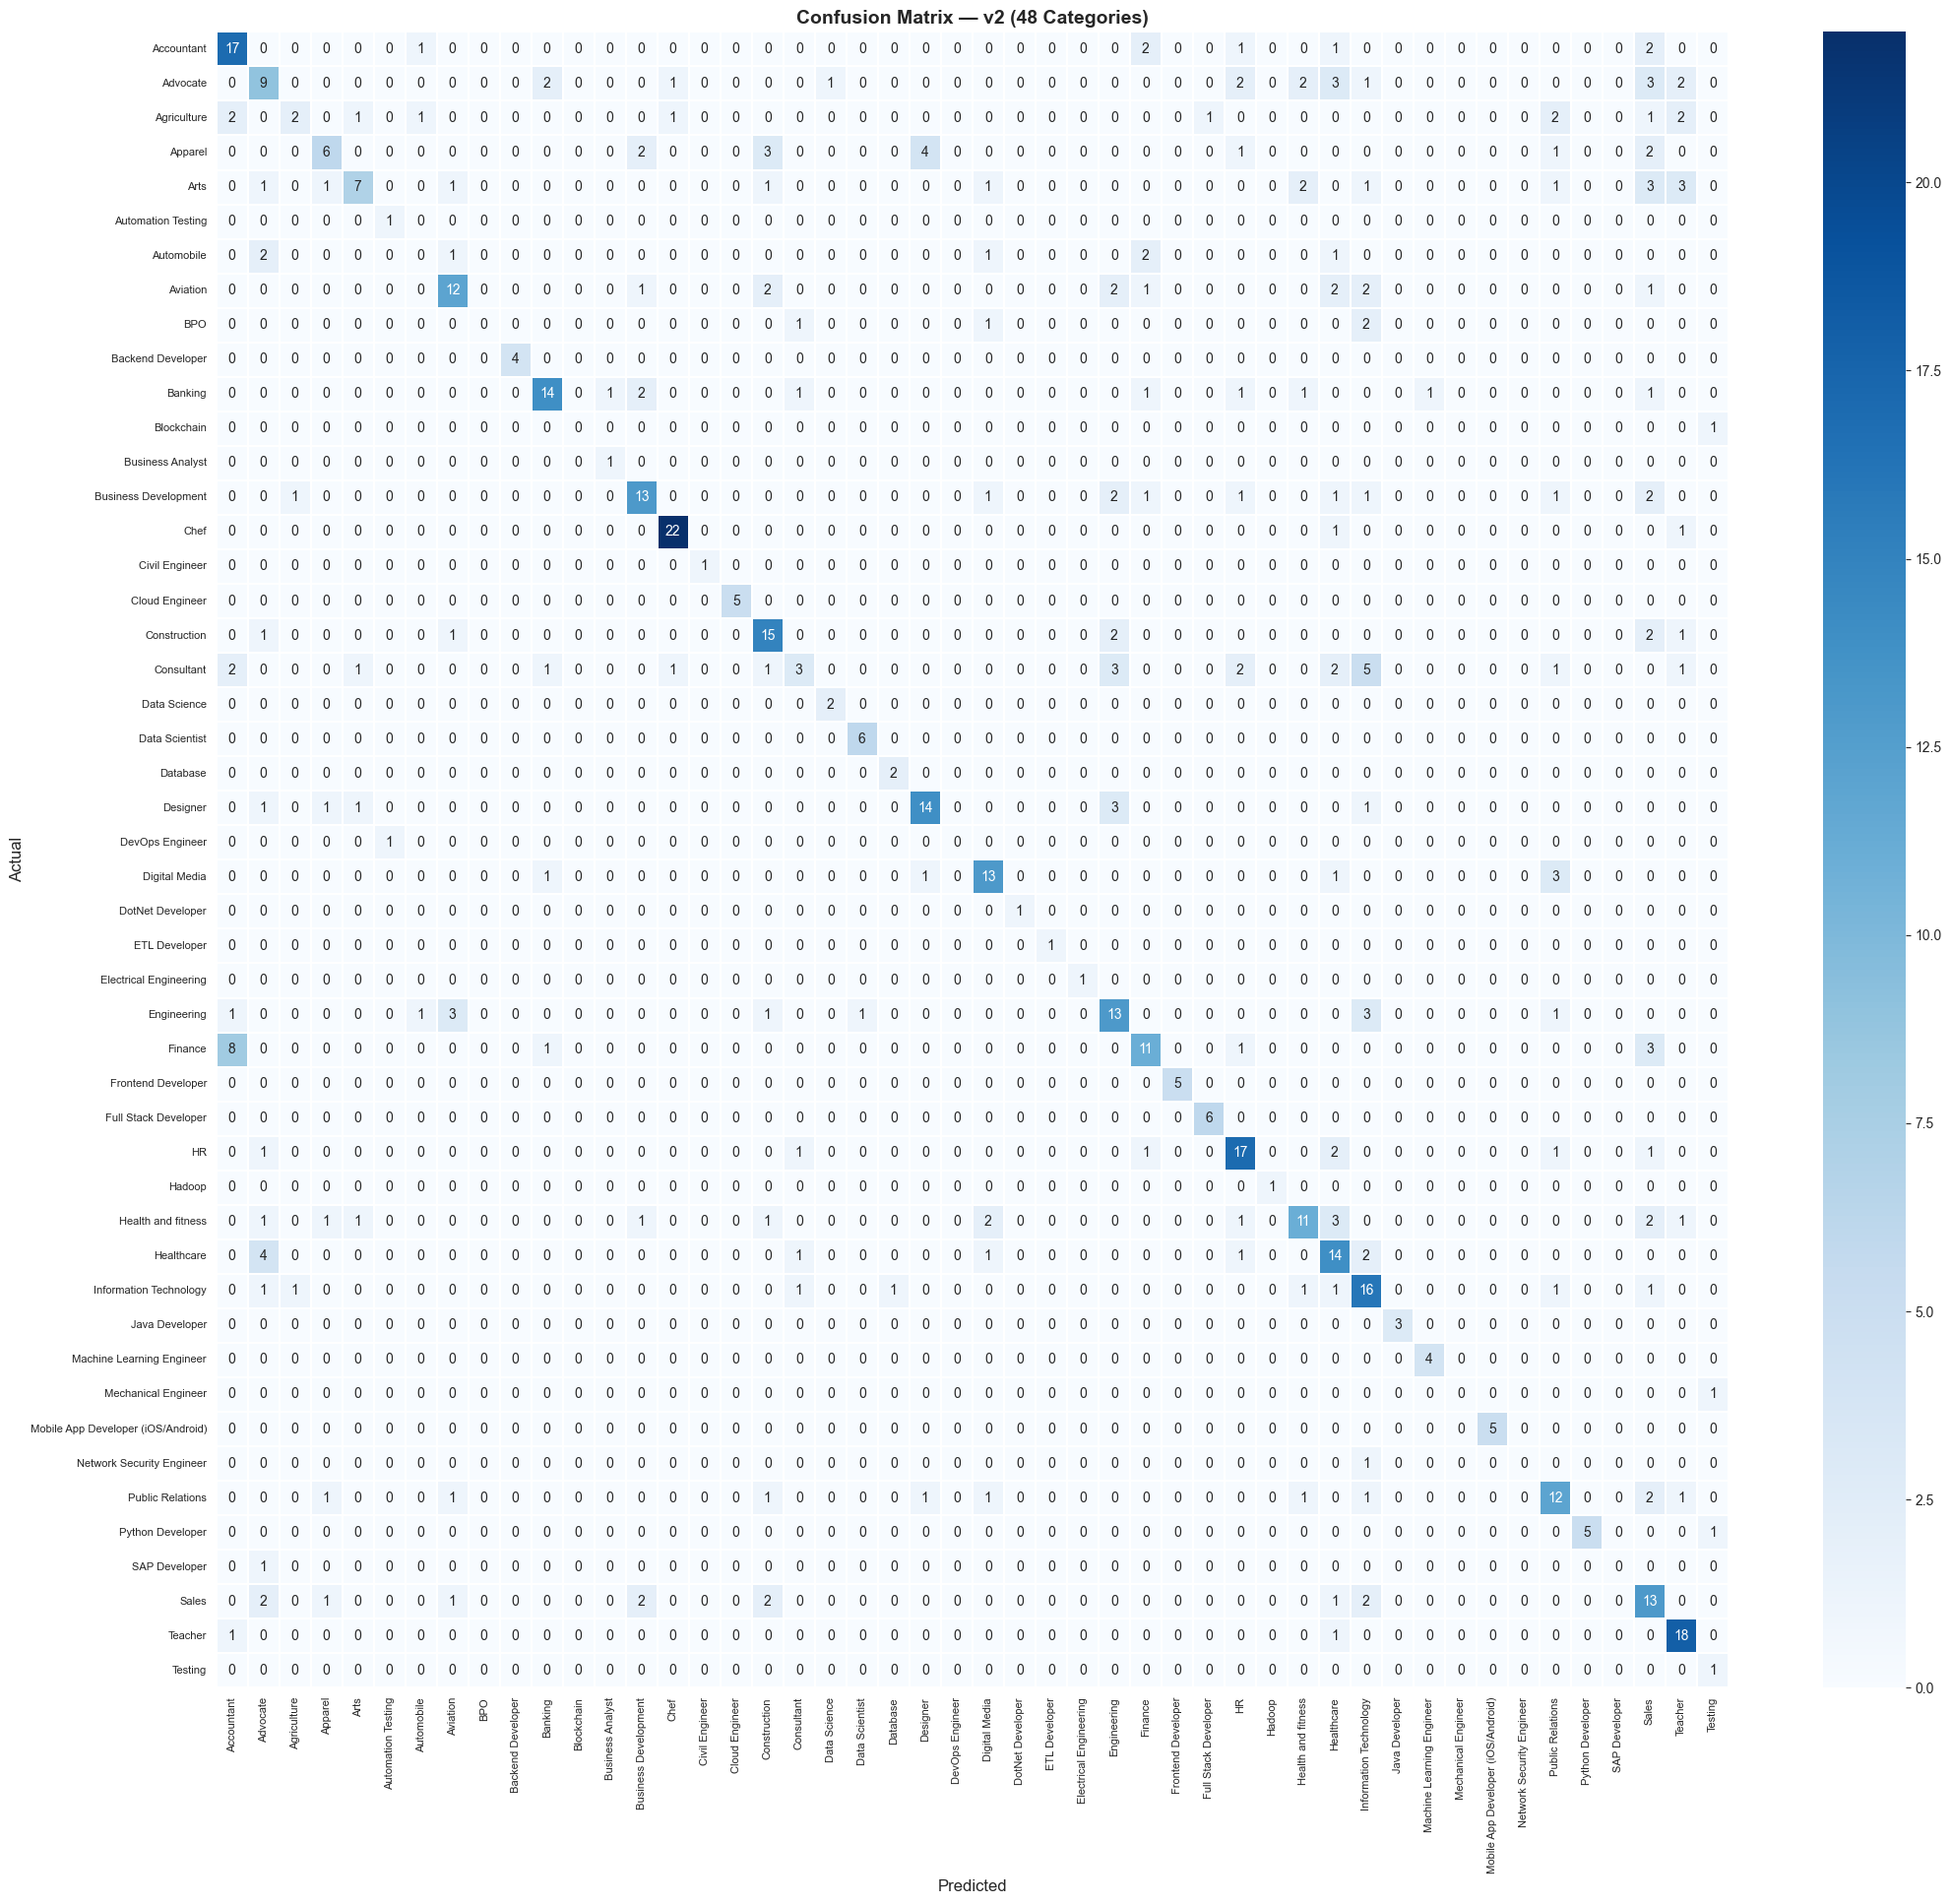

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
n_classes = len(le.classes_)
fig_size = max(18, n_classes * 0.45)

plt.figure(figsize=(fig_size, fig_size * 0.9))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    linewidths=0.3
)
plt.title(f'Confusion Matrix — v2 ({n_classes} Categories)', fontweight='bold', fontsize=14)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

---
## Step 8 — Prediction Function (Test )

In [ ]:
def predict_category(resume_text: str) -> str:
    """
    Predict the job category for a given resume text.
    Pipeline: clean → spaCy preprocess → TF-IDF → KNN predict
    """
    cleaned = clean_text(resume_text)
    processed = spacy_preprocess(cleaned)
    vectorized = tfidf.transform([processed])
    pred_idx = model.predict(vectorized)[0]
    return le.inverse_transform([pred_idx])[0]


#  Test 1: Data Science Resume
print(' Test 1: Data Science Resume ')
print(predict_category("""
Skills: Python (pandas, numpy, scikit-learn, matplotlib), SQL, Machine Learning,
Deep Learning, NLP, TensorFlow, Keras. Experience: 3 years as Data Scientist at XYZ Corp.
Built recommendation systems, fraud detection models. MS in Computer Science.
"""))

#  Test 2: Frontend Developer Resume
print('\n Test 2: Frontend Developer Resume (NEW category in v2) ')
print(predict_category("""
Experienced Frontend Developer with 4 years building responsive web applications.
Skills: React, Vue.js, Angular, HTML5, CSS3, JavaScript, TypeScript, Webpack, REST APIs.
Developed e-commerce platforms and interactive dashboards. Bachelor in IT.
"""))

#  Test 3: HR Resume
print('\n Test 3: HR Resume ')
print(predict_category("""
Human Resources professional with 5 years in recruitment, employee relations,
performance management, payroll, and training development. Conducted 200+ interviews.
Expert in HRIS (Workday, SAP HR). MBA in Human Resource Management.
"""))

#  Test 4: Chef Resume (new general category)
print('\n Test 4: Chef Resume (NEW general category in v2) ')
print(predict_category("""
Executive Chef with 10 years experience in fine dining restaurants. Specialized in
French and Italian cuisine. Managed kitchen staff of 20, menu planning, food costing,
inventory management. Culinary Arts degree from Le Cordon Bleu.
"""))

#  Test 5: ML Engineer Resume (new tech category)
print('\n Test 5: Machine Learning Engineer (NEW category in v2) ')
print(predict_category("""
Machine Learning Engineer with expertise in building and deploying ML pipelines.
Skills: PyTorch, TensorFlow, Scikit-learn, MLflow, Docker, Kubernetes, AWS SageMaker.
Designed feature engineering pipelines, model monitoring, A/B testing frameworks.
M.Tech in Artificial Intelligence.
"""))

=== Test 1: Data Science Resume ===
Machine Learning Engineer

=== Test 2: Frontend Developer Resume (NEW category in v2) ===
Frontend Developer

=== Test 3: HR Resume ===
HR

=== Test 4: Chef Resume (NEW general category in v2) ===
Chef

=== Test 5: Machine Learning Engineer (NEW category in v2) ===
Data Scientist


---
## Step 9 — Save Updated Models for FastAPI Deployment

In [ ]:
import joblib
import os

project_root = 'FullStackApp'
os.makedirs(project_root, exist_ok=True)

# Save to FullStackApp/ (for FastAPI)
joblib.dump(model, os.path.join(project_root, 'model.pkl'))
joblib.dump(tfidf,  os.path.join(project_root, 'tfidf.pkl'))
joblib.dump(le,     os.path.join(project_root, 'encoder.pkl'))

# Also overwrite root model.pkl
joblib.dump(model, 'model.pkl')

print(' model.pkl   → FullStackApp/model.pkl  & model.pkl')
print(' tfidf.pkl   → FullStackApp/tfidf.pkl')
print(' encoder.pkl → FullStackApp/encoder.pkl')
print()
print(
    f'  Dataset : {len(df)} resumes across {df["Category"].nunique()} categories')
print(f'  Accuracy: {acc:.4f} ({acc:.2%})')
print()
print(' All models saved. Ready for FastAPI deployment!')

✓ model.pkl   → FullStackApp/model.pkl  & model.pkl
✓ tfidf.pkl   → FullStackApp/tfidf.pkl
✓ encoder.pkl → FullStackApp/encoder.pkl

  Dataset : 2824 resumes across 48 categories
  Accuracy: 0.5788 (57.88%)

✓ All models saved. Ready for FastAPI deployment!


In [1]:
print(predict_category("""
Responsibilities

Develop websites using HTML, CSS, JavaScript, and modern frameworks.
Work with backend technologies like Node.js, Django, Flask, or PHP.
Integrate APIs and optimize website performance.
Debug, test, and maintain web applications.
Qualifications

Students or graduates in Computer Science, IT, or related fields.
Knowledge of HTML, CSS, JavaScript, and basic backend technologies.
Familiarity with databases and Git preferred.
Required Skills

HTML, CSS, JavaScript.
Basic backend technologies.
Preferred Skills

Node.js, Django, Flask, PHP.
Databases, Git
"""))

NameError: name 'predict_category' is not defined